In [18]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from scipy.special import rel_entr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import time

In [19]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input
from quantum_functions import find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_iterative_n_wise

In [20]:
from qiskit import QuantumCircuit, QuantumRegister

def create_hadamard_circuit(num_qubits: int) -> QuantumCircuit:
    """
    Initializes a quantum circuit with all qubits in the |+> state by
    applying a Hadamard gate to each one.

    Args:
        num_qubits (int): The number of qubits to include in the circuit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)
    
    # Loop through each qubit and apply the Hadamard (H) gate.
    # The H gate puts the qubit into a superposition of |0> and |1>.
    for i in range(num_qubits):
        circuit.h(qr[i])
        
    return circuit

In [47]:
from qiskit import QuantumCircuit, QuantumRegister
import math

def create_rotation_circuit(angles_list: list[float]) -> QuantumCircuit:
    """
    Initializes a quantum circuit by applying a rotation gate with a
    specified angle to each qubit. The number of qubits is determined
    by the length of the angles_list.

    Args:
        angles_list (list[float]): A list of rotation angles in radians,
                                   one for each qubit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # The number of qubits is determined by the length of the angles list.
    num_qubits = len(angles_list)
    
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)

    for i in range(num_qubits):
        circuit.ry(angles_list[i], qr[i])
        
    return circuit

In [48]:
# Create the circuit using the function
ang_4g = [np.pi*0.4, np.pi*0.1, np.pi*0.6, np.pi*0.2]
#ang_4g = [np.pi*0, np.pi*0, np.pi*1, np.pi*1]
circuit_4g = create_rotation_circuit(ang_4g)

# Create the circuit using the function
ang_3g = [np.pi*0.6, np.pi*0.3, np.pi*0.25]
#ang_3g = [np.pi*1, np.pi*1, np.pi*0]
circuit_3g = create_rotation_circuit(ang_3g)

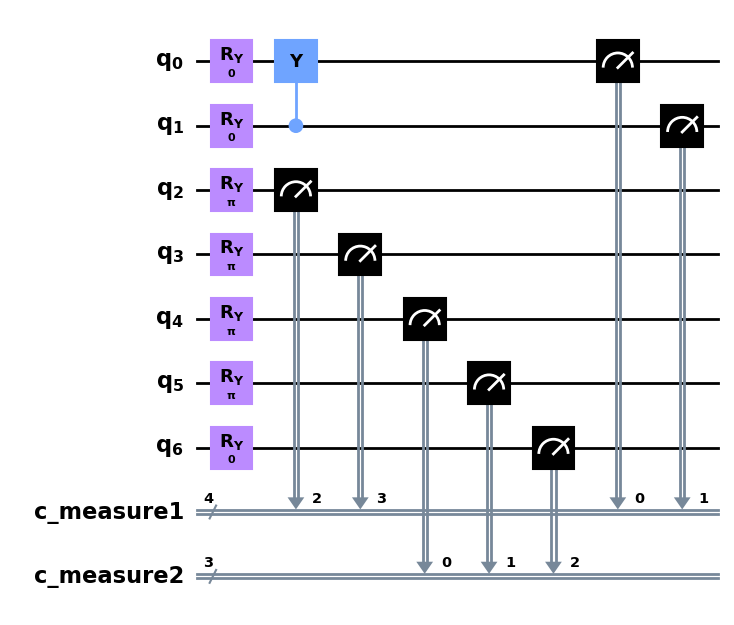

In [ ]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_4g, circuit_3g)
interaction_map = list([(0,1), (2,1), (3,2), (3,4), (4, 6)])
#interaction_map = list([(1, 0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_4g.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'1100': 2000}
Counts for c_measure2: {'011': 2000}


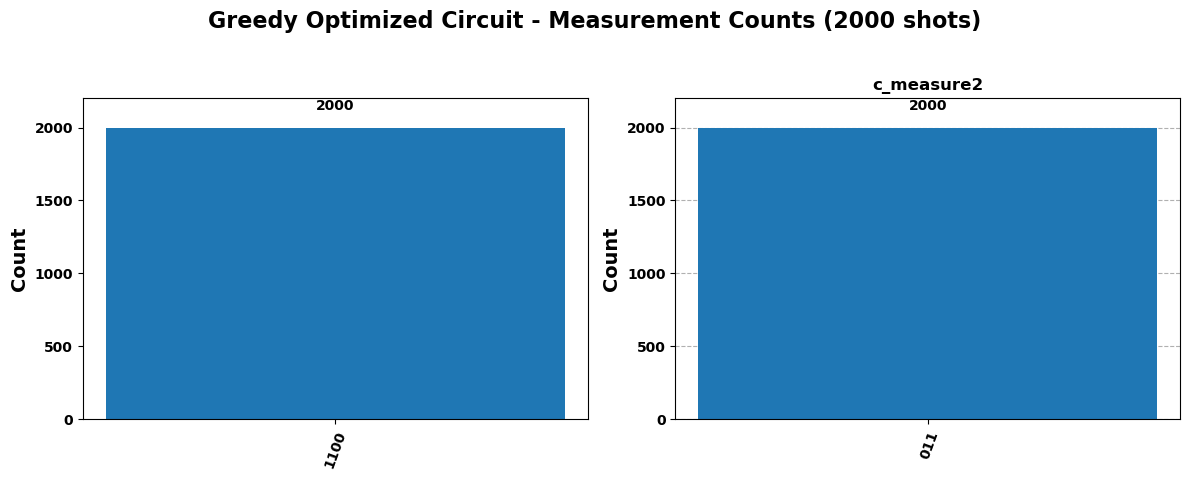

In [46]:
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Greedy Optimized Circuit")